  Initialized states for phase 0 (tag 1): 4564 cells
  Initialized history variables for 1 phases
  Quadrature points per cell: 9

STARTING HOMOGENIZATION ANALYSIS
   Dimension: 2D
   Number of load cases: 1
   Max strain: 0.4
   History-dependent materials: True


######################################################################
Load Case 1/1: tension
######################################################################
[Hook 1] Created tracking file: tracking_tension.txt
   Re-initializing material states for new load case...
  Initialized states for phase 0 (tag 1): 4564 cells

STARTING LOAD CASE: tension
   Target Load: 0.4000 | Initial da: 3.20e-02
   Constant strain rate: 1.00e+10 (1/time)
   History-dependent materials detected - tracking state evolution
   Quadrature points per cell: 9

Step   1 | Progress:   8.00% | Load: 0.032000 | da: 3.20e-02
   Strain increment da: 3.20e-02 | Physical dt: 3.20e-12
   Attempting da: 3.20e-02
[Hook 2] Step 1: load=0.0320 (8.0%), da=3.2

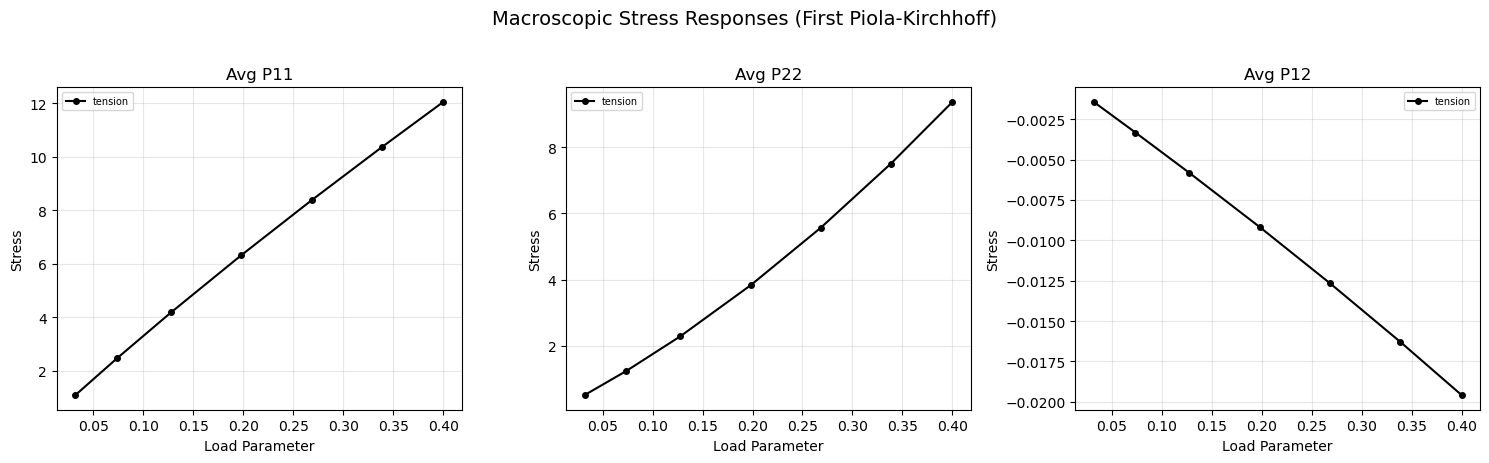

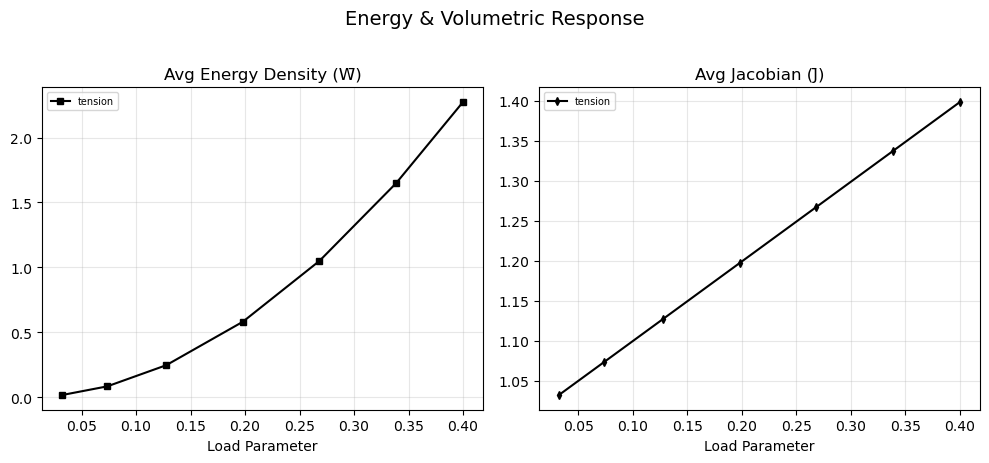

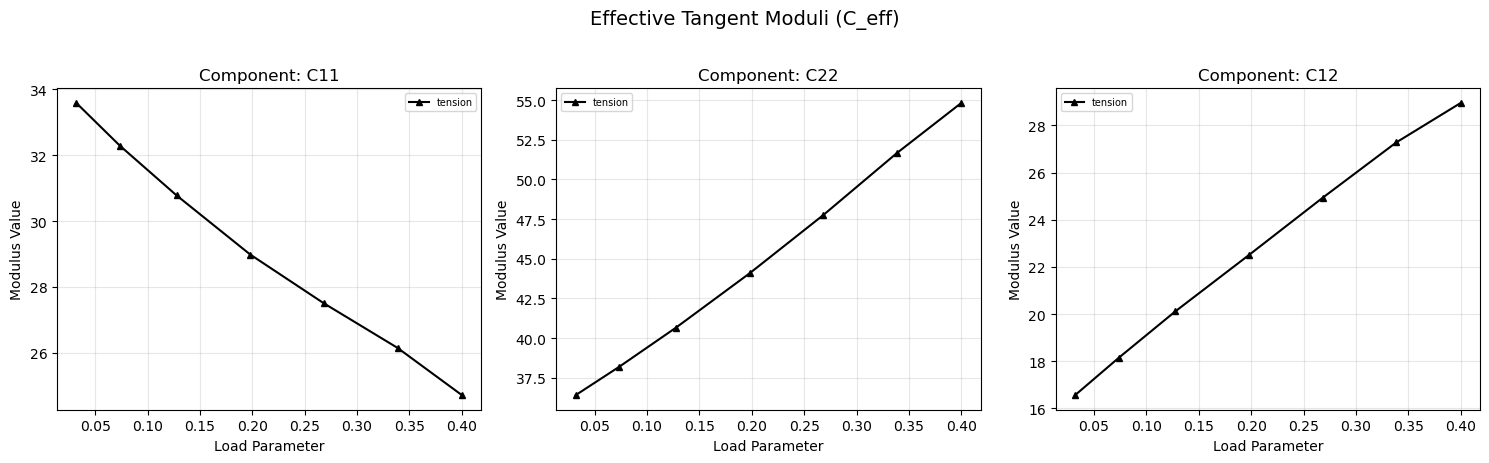

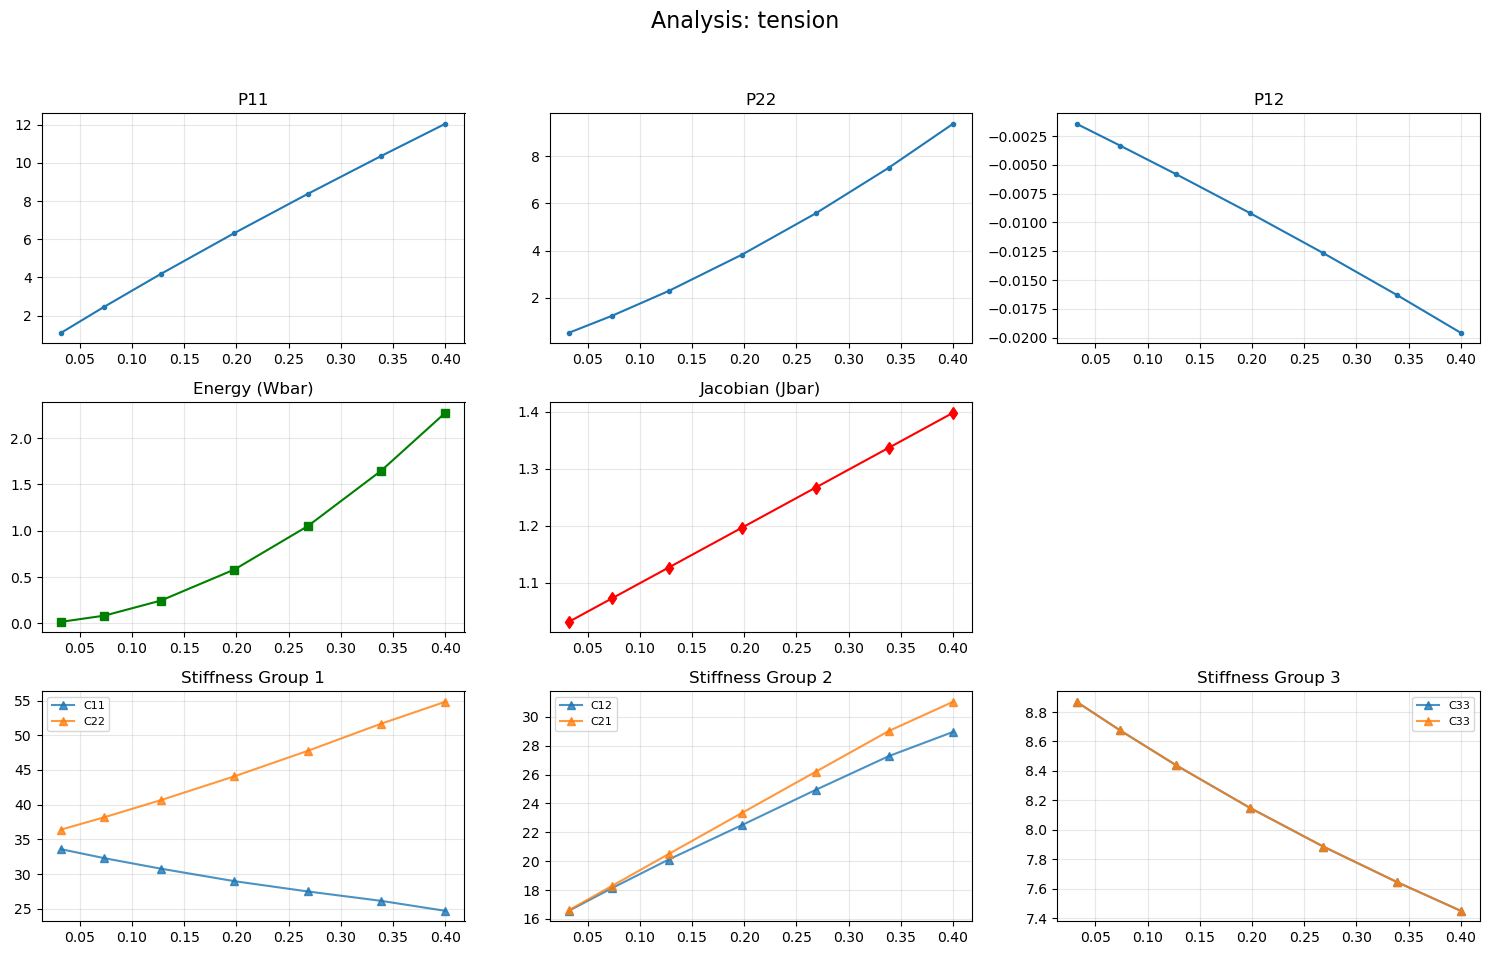


ANALYSIS COMPLETE
{'tension': {'load': array([0.032   , 0.0736  , 0.12768 , 0.197984, 0.268288, 0.338592,
       0.4     ]), 'P11': array([ 1.09316695,  2.46665652,  4.18423409,  6.32345964,  8.3779079 ,
       10.36443483, 12.05390851]), 'P22': array([0.51031339, 1.23631726, 2.28559582, 3.82736713, 5.56950374,
       7.51162143, 9.37142382]), 'Wbar': array([0.01587631, 0.08293128, 0.24584495, 0.58077711, 1.04975358,
       1.64833164, 2.27440975]), 'Jbar': array([1.03184969, 1.07326415, 1.12711965, 1.19715963, 1.26722973,
       1.3373278 , 1.39857682]), 'P12': array([-0.00143552, -0.00332489, -0.00582833, -0.00917955, -0.01265975,
       -0.01628589, -0.01958234]), 'P21': array([-1.24346162e-03, -2.32333466e-03, -2.86215928e-03, -2.17040998e-03,
        2.77817376e-05,  3.68010379e-03,  8.03026195e-03]), 'C11': array([33.59018863, 32.29059553, 30.78171889, 28.98481241, 27.50233858,
       26.14835783, 24.7133834 ]), 'C22': array([36.40959153, 38.19863474, 40.66085186, 44.08536114, 4

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
import petsc4py.PETSc as PETSc
import numpy as np
from ufl import det, tr

from homicsx import(
    Inclusion,
    RVEGeometry, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    ProblemSettings,
)
from homicsx.core.material import HyperelasticMaterial, ViscoelasticGeneralizedMaxwell, MaterialState
from homicsx.mesh import generate_mesh
from homicsx.core.homogenization import AdaptiveSettings
from homicsx.homogenization.driver import (
    NonlinearHomogenizationDriver,
    PreLoadCaseData,
    PostLoadCaseData,
    PreStepData,
    PostConvergenceData,
    PostStressData,
    PostTangentData,
    StepFailureData,
)

# ------------------------------------------------------------------------------
# Mesh Generation
# ------------------------------------------------------------------------------
dim = 2
domain_size = (1, 1)

inclusion = Inclusion(
    center=[0.5, 0.5],
    phase_id=1,
    shape='circle',
    radii=0.2,
)

geometry = RVEGeometry(
    dim=dim,
    domain_size=domain_size,
    inclusions=[inclusion],
)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.02,
    max_size=0.04,
    physical_tags=physical_tags,
    quad_hex=True,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

# ------------------------------------------------------------------------------
# Material assignment
# ------------------------------------------------------------------------------
@dataclass
class NeoHookeanDecoupled(HyperelasticMaterial):
    def __init__(self, kappa, mu):
        self.kappa = kappa
        self.mu = mu
    
    def psi_form(self, F):
        dim = F.ufl_shape[0]
        C = F.T * F
        J = det(F)
        I1 = J**(-2/3) * (tr(C) + 1)
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def evaluate_energy(self, F: np.ndarray, dim: int) -> float:
        J = np.linalg.det(F)
        C = F.T @ F
        tr_C = np.trace(C)
        if dim == 2:
            I1 = J**(-2/3) * (tr_C + 1)
        else:
            I1 = J**(-2/3) * tr_C
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def get_quadrature_point_stress(self, state: MaterialState, F: np.ndarray, quad_point_idx: int) -> np.ndarray:
        dim = F.shape[0]
        J = np.linalg.det(F)
        Finv = np.linalg.inv(F)
        FinvT = Finv.T
        
        C = F.T @ F
        tr_C = np.trace(C)
        
        if dim == 2:
            tr_term = tr_C + 1
        else:
            tr_term = tr_C
        
        P_iso = self.mu * J**(-2.0/3.0) * (F - (1.0/3.0) * tr_term * FinvT)
        P_vol = self.kappa * J * (J - 1.0) * FinvT
        
        return P_iso + P_vol

kappa_mat = 17.5
mu_eq = 6.0
mu_neq = 2.0
tau = 1e-5
mat_matrix_eq = NeoHookeanDecoupled(kappa=kappa_mat, mu=mu_eq)
mat_matrix_visco = ViscoelasticGeneralizedMaxwell(
    equilibrium_material=mat_matrix_eq,
    num_branches=1,
    shear_moduli=[mu_neq],
    relaxation_times=[tau]
)

kappa_inc = 100 * kappa_mat
mu_inc = 100 * mu_eq
mat_inclusion = NeoHookeanDecoupled(kappa=kappa_inc, mu=mu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix_visco,  # Viscoelastic matrix
        1: mat_inclusion,     # Hyperelastic inclusion
    }
)

# ------------------------------------------------------------------------------
# FEM problem settings
# ------------------------------------------------------------------------------
fem_settings = ProblemSettings(
    dim = dim,
    kinematics='finite_strain',
    two_dimensional_formulation='plane_strain',
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-8,
        "snes_atol": 1e-10,
        "snes_max_it": 12,
    }
)

def uni_tension_func(a):
    F = np.eye(2, dtype=PETSc.ScalarType)
    F[0, 0] = 1.0 + a
    return F

# ------------------------------------------------------------------------------
# Create driver (hooks enabled)
# ------------------------------------------------------------------------------
driver = NonlinearHomogenizationDriver(
    mesh_obj=domain,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=domain_size,
    matrix_phase_id=0,
    quad_degree=4,
    enable_hooks=True,  # Enable hooks
)

# Create a shared metadata dict that persists across all hooks
shared_metadata = {}

def pre_load_case_hook_fixed(data: PreLoadCaseData) -> None:
    """Create tracking file using shared metadata."""
    filename = f"tracking_{data.load_name}.txt"
    
    # Store in shared metadata (closure variable)
    shared_metadata['tracking_file'] = filename
    shared_metadata['load_name'] = data.load_name
    
    with open(filename, 'w') as f:
        f.write(f"Load Case: {data.load_name}\n")
        f.write(f"Target Load: {data.target_load}\n")
        f.write(f"Dimension: {data.dim}D\n")
        f.write("="*50 + "\n")
        f.write("step_idx,load,W_avg,J_avg,P11,P22,P12,newton_iters,residual_norm\n")
        f.flush()
    
    print(f"[Hook 1] Created tracking file: {filename}")

driver.add_pre_load_case_hook(pre_load_case_hook_fixed)


def pre_step_hook_fixed(data: PreStepData) -> None:
    """Monitor progress."""
    progress = (data.target_load / 0.4) * 100  # Assuming max_strain=0.4
    print(f"[Hook 2] Step {data.step_idx}: load={data.target_load:.4f} "
          f"({progress:.1f}%), da={data.load_increment:.2e}")

driver.add_pre_step_hook(pre_step_hook_fixed)


def post_convergence_hook_fixed(data: PostConvergenceData) -> None:
    """Store convergence info in shared metadata."""
    shared_metadata['newton_iters'] = data.newton_iterations
    shared_metadata['residual_norm'] = data.residual_norm
    
    if data.residual_norm < 1e-10:
        quality = "excellent"
    elif data.residual_norm < 1e-8:
        quality = "good"
    elif data.residual_norm < 1e-6:
        quality = "acceptable"
    else:
        quality = "poor"
    
    print(f"[Hook 3] Step {data.step_idx}: iters={data.newton_iterations}, "
          f"residual={data.residual_norm:.2e} ({quality})")

driver.add_post_convergence_hook(post_convergence_hook_fixed)


def post_stress_hook_fixed(data: PostStressData) -> None:
    """Write to tracking file using shared metadata."""
    tracking_file = shared_metadata.get('tracking_file', 'tracking_default.txt')
    
    # Get stored convergence info
    newton_iters = shared_metadata.get('newton_iters', 0)
    residual_norm = shared_metadata.get('residual_norm', 0.0)
    
    # Compute metrics
    P_max = np.max(np.abs(data.P_avg))
    if data.P_avg.shape == (2, 2):
        vm_stress = np.sqrt(data.P_avg[0,0]**2 + data.P_avg[1,1]**2 - 
                            data.P_avg[0,0]*data.P_avg[1,1] + 
                            3*data.P_avg[0,1]**2)
    else:
        vm_stress = 0.0
    
    print(f"[Hook 4] Step {data.step_idx}: W={data.W_avg:.4e}, J={data.J_avg:.4f}, "
          f"P11={data.P_avg[0,0]:.4e}, VM={vm_stress:.4e}")
    
    # Write to file
    try:
        with open(tracking_file, 'a') as f:
            line = (f"{data.step_idx},{data.current_load:.6f},{data.W_avg:.6e},"
                    f"{data.J_avg:.6f},{data.P_avg[0,0]:.6e},{data.P_avg[1,1]:.6e},"
                    f"{data.P_avg[0,1]:.6e},{newton_iters},{residual_norm:.2e}\n")
            f.write(line)
            f.flush()
    except Exception as e:
        print(f"[Hook 4] ERROR writing to {tracking_file}: {e}")

driver.add_post_stress_hook(post_stress_hook_fixed)


def post_tangent_hook_fixed(data: PostTangentData) -> None:
    """Analyze tangent stiffness."""
    C = data.C_tangent
    
    # For 2D, C is 4x4 (11, 22, 12, 21 components flattened)
    if C.shape == (4, 4):
        # Extract Voigt components: 11, 22, 12
        C_voigt = np.array([
            [C[0,0], C[0,3], 0],
            [C[3,0], C[3, 3], 0],
            [0, 0, C[2,2]]
        ])
        eigenvalues = np.linalg.eigvalsh(C_voigt)
        min_eig = np.min(eigenvalues.real)
        
        print(f"[Hook 5] Step {data.step_idx}: min eigenvalue = {min_eig:.4e}")
        
        if min_eig < 0:
            print(f"[Hook 5]   -> WARNING: Negative eigenvalue (instability)")
            shared_metadata['unstable'] = True
        else:
            shared_metadata['unstable'] = False

driver.add_post_tangent_hook(post_tangent_hook_fixed)


def step_failure_hook_fixed(data: StepFailureData) -> None:
    """Log failures."""
    print(f"[Hook 6] FAILURE at step {data.step_idx}: load={data.target_load:.6f}")
    
    with open(f"failure_{data.load_name}.log", 'a') as f:
        f.write(f"Step {data.step_idx}: load={data.target_load:.6f}, "
                f"da={data.attempted_increment:.2e}, error={data.error_message}\n")

driver.add_step_failure_hook(step_failure_hook_fixed)


def post_load_case_hook(data: PostLoadCaseData) -> None:
    """Generate summary."""
    print(f"\n[Hook 7] LOAD CASE '{data.load_name}' COMPLETED")
    print(f"[Hook 7]   Total steps: {data.total_steps}")
    print(f"[Hook 7]   Converged: {data.converged}")

driver.add_post_load_case_hook(post_load_case_hook)

# ------------------------------------------------------------------------------
# Run the analysis
# ------------------------------------------------------------------------------
result = driver.run(
    strain_rate=1e10,
    tangent_every=1,
    output_prefix='rve',
    max_strain=0.4,
    custom_loads={
        'tension': uni_tension_func,
    },
    from_built_in_loads=[],
    adaptive_settings=AdaptiveSettings(
        initial_step_ratio=0.08,
        min_step=1e-6,
        target_iters_min=4,
        target_iters_max=8,
        cutback_factor=0.8,
        growth_factor=1.3,
    ),
    xdmf_opt=True,
    csv_opt=False,
    plot_summary=True,
    plot_individual=True,
)

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(result.summary)